In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import gc
import io
import os
import math
from itertools import combinations
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from sitecustomize import ROOT # lib này được khởi tạo ban đầu dự án

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [15]:
df = pd.read_csv(ROOT + "/data/bank/bank-full.csv", sep=';')

In [16]:
# # # --- Feature Engineering ---

df['balance_per_campaign'] = df['balance'] / df['campaign']
df['balance_per_previous'] = np.where(df['previous'] > 0, df['balance'] / df['previous'], 0)
df['duration_per_campaign'] = df['duration'] / df['campaign']
df['age_from_mean'] = df['age'] - df['age'].mean()
df['campaign_minus_previous'] = df['campaign'] - df['previous']
df['total_contacts'] = df['campaign'] + df['previous']

# df['balance_gt_0'] = (df['balance'] >= 000).astype(object)

df['campaign_gt_3'] = (df['campaign'] > 3).astype(int)
df['duration_gt_mean'] = (df['duration'] > 3000).astype(object)


# df['previous_gt_0'] = (df['previous'] > 0).astype(object)
# df['poutcome_success'] = (df['poutcome'] == 'success').astype(object) # đã one hot encode rồi

# categorical_cols_for_combo = ['marital', 'education', 'default', 'housing', 'loan', 'contact']
# for col in categorical_cols_for_combo:
#     df[f'job_{col}_combo'] = df['job'].astype(str) + '-' + df[col].astype(str)

# df['default_balance_campaign_combo'] = df['default'].astype(str) + '-' + df['balance_gt_0'].astype(str) + '-' + df['campaign_gt_2'].astype(str)
# df['housing_balance_campaign_contact_combo'] = df['housing'].astype(str) + '-' + df['balance_gt_0'].astype(str) + '-' + df['campaign_gt_2'].astype(str) + '-' + df['contact'].astype(str)
# df['loan_balance_campaign_pdays_contact_combo'] = df['loan'].astype(str) + '-' + df['balance_gt_0'].astype(str) + '-' + df['campaign_gt_2'].astype(str) + '-' + df['pdays_gt_0'].astype(str) + '-' + df['contact'].astype(str)

## BINS TUỔI

In [17]:
bins = [0, 30, 60, np.inf]
labels = ['young', 'ad', 'old']

df['age'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

## BINS PDAYS

In [18]:
# bins = [0, 225, 400, np.inf]
# labels = ['a', 'b', 'c']

# df['pdays_gt_0'] = pd.cut(df['pdays'], bins=bins, labels=labels, right=False)

## BINS DAY

In [ ]:
df['day'] = (df['day']).astype(int)

In [19]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,...,poutcome,y,balance_per_campaign,balance_per_previous,duration_per_campaign,age_from_mean,campaign_minus_previous,total_contacts,campaign_gt_3,duration_gt_mean
0,ad,management,married,tertiary,no,2143,yes,no,unknown,5,...,unknown,no,2143.0,0.000000,261.000000,17.06379,1,1,0,False
1,ad,technician,single,secondary,no,29,yes,no,unknown,5,...,unknown,no,29.0,0.000000,151.000000,3.06379,1,1,0,False
2,ad,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,unknown,no,2.0,0.000000,76.000000,-7.93621,1,1,0,False
3,ad,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,unknown,no,1506.0,0.000000,92.000000,6.06379,1,1,0,False
4,ad,unknown,single,unknown,no,1,no,no,unknown,5,...,unknown,no,1.0,0.000000,198.000000,-7.93621,1,1,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,ad,technician,married,tertiary,no,825,no,no,cellular,17,...,unknown,yes,275.0,0.000000,325.666667,10.06379,3,3,0,False
45207,old,retired,divorced,primary,no,1729,no,no,cellular,17,...,unknown,yes,864.5,0.000000,228.000000,30.06379,2,2,0,False
45208,old,retired,married,secondary,no,5715,no,no,cellular,17,...,success,yes,1143.0,1905.000000,225.400000,31.06379,2,8,1,False
45209,ad,blue-collar,married,secondary,no,668,no,no,telephone,17,...,unknown,no,167.0,0.000000,127.000000,16.06379,4,4,1,False


## data preparing

In [20]:
# Chuyển đổi target về số
df['y'] = df['y'].map({'yes': 1, 'no': 0})

TARGET = 'y'
features = [col for col in df.columns if col != TARGET]
X = df[features]
y = df[TARGET]

# Xác định các cột số và cột phân loại
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
if "y" in cat_cols:
    cat_cols.remove("y")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## pipeline building

In [21]:
# --- Pipeline tiền xử lý ---
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# lightGBM

Cross-validated F1-scores:
0.6018054162487463
0.5977318212141428
0.5894876912840985
0.6081754735792622
0.5925925925925926
Mean F1-score: 0.5980 (+/- 0.0066)

[LightGBM] [Info] Number of positive: 4231, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001469 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1925
[LightGBM] [Info] Number of data points in the train set: 36168, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


d:\DataMiningBTL\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC AUC: 0.9294


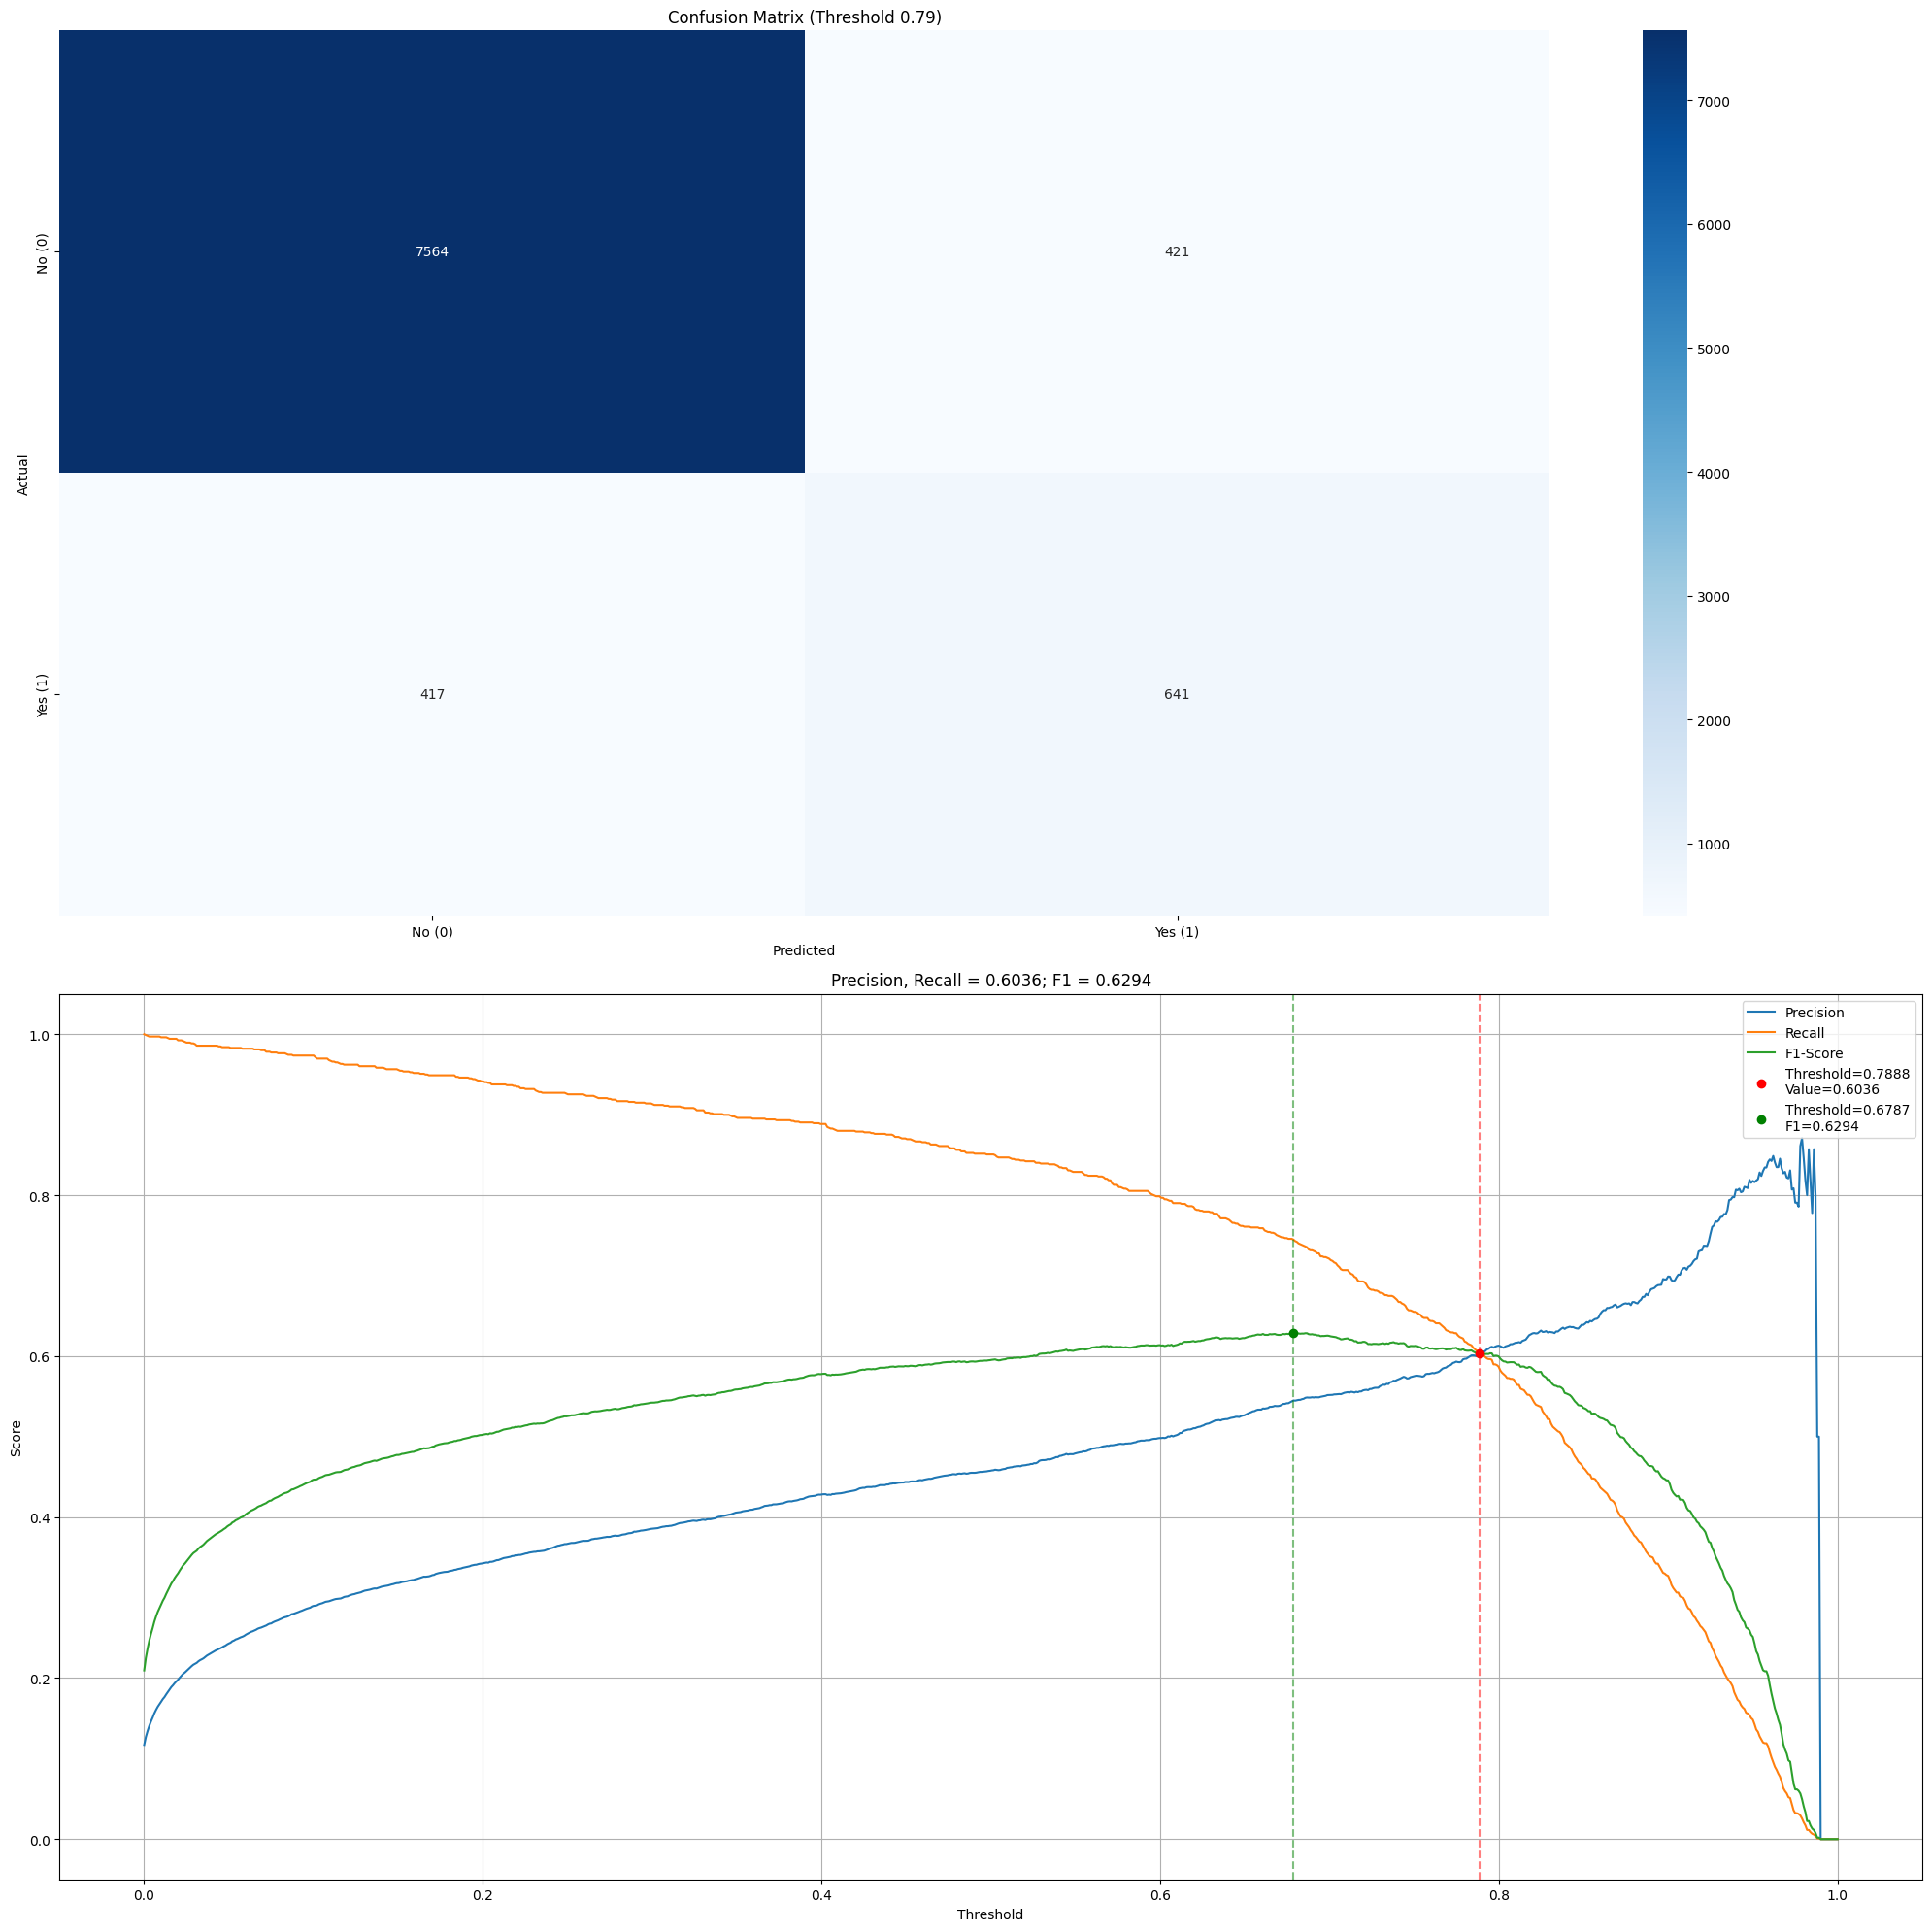

In [22]:
import lightgbm as lgb


# --- Gắn model LightGBM vào pipeline ---
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=8,
        min_child_samples=1,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Sử dụng StratifiedKFold để giữ tỉ lệ lớp
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Đánh giá F1-score, bạn có thể thay bằng 'accuracy', 'roc_auc', 'recall', v.v.
scores = cross_val_score(
    lgbm_pipeline, X, y, cv=cv, scoring='f1', n_jobs=-1
)

print("Cross-validated F1-scores:", *scores, sep="\n")
print("Mean F1-score: {:.4f} (+/- {:.4f})\n".format(scores.mean(), scores.std()))

# --- Train ---
lgbm_pipeline.fit(X_train, y_train)

# --- Evaluation ---
y_pred_proba = lgbm_pipeline.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC: {auc:.4f}")


# --- Chuẩn bị dữ liệu cho biểu đồ threshold ---
thresholds = np.linspace(0, 1, 1000)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

precisions = np.array(precisions)
recalls = np.array(recalls)
f1s = np.array(f1s)

# 1. Điểm giao giữa precision và recall
diff = np.abs(precisions - recalls)
valid = (precisions > 0) & (recalls > 0)
diff[~valid] = np.nan
intersection_idx = np.nanargmin(diff)
intersection_threshold = thresholds[intersection_idx]
intersection_value = precisions[intersection_idx]

# 2. Ngưỡng tối ưu theo F1
optimal_idx = np.argmax(f1s)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1s[optimal_idx]

# --- Vẽ song song ---
fig, axes = plt.subplots(2, 1, figsize=(20, 20))

# (1) Confusion Matrix
cm = confusion_matrix(y_test, (y_pred_proba >= intersection_threshold).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No (0)', 'Yes (1)'], 
            yticklabels=['No (0)', 'Yes (1)'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix (Threshold {intersection_threshold:.2f})')

# (2) Precision-Recall-F1 vs Threshold
axes[1].plot(thresholds, precisions, label='Precision')
axes[1].plot(thresholds, recalls, label='Recall')
axes[1].plot(thresholds, f1s, label='F1-Score')

axes[1].scatter([intersection_threshold], [intersection_value], color='red', zorder=5, label=f'Threshold={intersection_threshold:.4f}\nValue={intersection_value:.4f}')
axes[1].axvline(intersection_threshold, color='red', linestyle='--', alpha=0.5)

axes[1].scatter([optimal_threshold], [optimal_f1], color='green', zorder=5, label=f'Threshold={optimal_threshold:.4f}\nF1={optimal_f1:.4f}')
axes[1].axvline(optimal_threshold, color='green', linestyle='--', alpha=0.5)

axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True)
axes[1].set_title(f'Precision, Recall = {intersection_value:.4f}; F1 = {optimal_f1:.4f}')

plt.tight_layout()
plt.show()

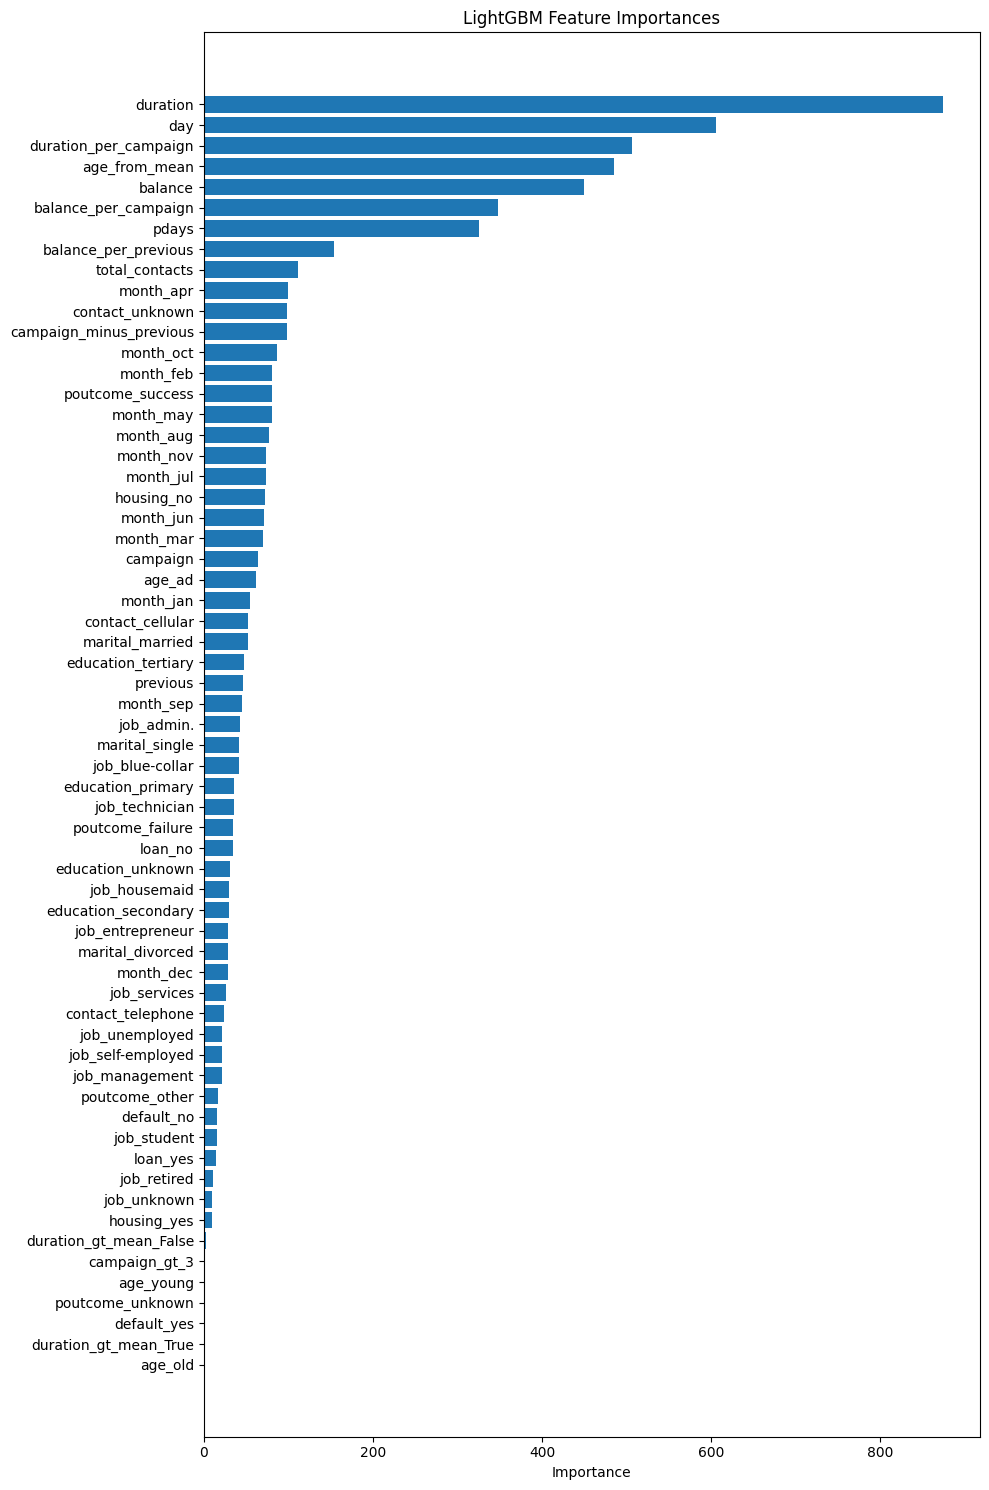

In [23]:
# Sau khi fit pipeline xong:
lgbm_model = lgbm_pipeline.named_steps['classifier']
preprocessor = lgbm_pipeline.named_steps['preprocessor']

# Lấy tên các cột sau biến đổi
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(preprocessor.transformers_[1][2])
all_features = np.concatenate([num_features, cat_features])

importances = lgbm_model.feature_importances_
feature_importance = sorted(zip(all_features, importances), key=lambda x: x[1], reverse=True)

fi_df = pd.DataFrame({'feature': all_features, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 15))
plt.barh(fi_df['feature'][:][::-1], fi_df['importance'][:][::-1])
plt.xlabel('Importance')
plt.title('LightGBM Feature Importances')
plt.tight_layout()
plt.show()

## Up/Down sample

In [24]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import lightgbm as lgb
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# 1. Chuẩn bị dữ liệu
df['y'] = df['y'].map({'yes': 1, 'no': 0})
TARGET = 'y'
features = [col for col in df.columns if col != TARGET]
X = df[features]
y = df[TARGET]
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
if "y" in cat_cols:
    cat_cols.remove("y")
    
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Định nghĩa pipeline tiền xử lý và model
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])
lgbm = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=8,
    min_child_samples=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 3. Hàm train, validate và test
def train_and_validate(X_tr, y_tr, X_te, y_te, preprocessor, model, dataset_name=""):
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_cv = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring='f1', n_jobs=-1)
    auc_cv = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    y_pred_proba = pipe.predict_proba(X_te)[:,1]
    
    f1_test = f1_score(y_te, y_pred)
    auc_test = roc_auc_score(y_te, y_pred_proba)
    
    print(f"\n==== {dataset_name} ====")
    print(f"CV F1:  {f1_cv.mean():.4f} (+/- {f1_cv.std():.4f})")
    print(f"CV AUC: {auc_cv.mean():.4f} (+/- {auc_cv.std():.4f})")
    print(f"Test F1:  {f1_test:.4f}")
    print(f"Test AUC: {auc_test:.4f}")
    return pipe

# 4. Original
train_and_validate(X_train, y_train, X_test, y_test, preprocessor, lgbm, dataset_name="Original")

# 5. Upsample
ros = RandomOverSampler(random_state=42)
X_train_upsample, y_train_upsample = ros.fit_resample(X_train, y_train)
train_and_validate(X_train_upsample, y_train_upsample, X_test, y_test, preprocessor, lgbm, dataset_name="Upsampled")

# 6. Downsample
rus = RandomUnderSampler(random_state=42)
X_train_downsample, y_train_downsample = rus.fit_resample(X_train, y_train)
train_and_validate(X_train_downsample, y_train_downsample, X_test, y_test, preprocessor, lgbm, dataset_name="Downsampled")

ValueError: Input y contains NaN.

# random forest

In [ ]:
print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Train 'yes' ratio: {y_train.mean():.2%}")
print(f"Test 'yes' ratio: {y_test.mean():.2%}")

# --- Gắn model vào pipeline ---
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

# Sử dụng StratifiedKFold để giữ tỉ lệ lớp
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Đánh giá F1-score, bạn có thể thay bằng 'accuracy', 'roc_auc', 'recall', v.v.
scores = cross_val_score(
    rf_pipeline, X, y, cv=cv, scoring='f1', n_jobs=-1
)

print("Cross-validated F1-scores:", *scores, sep="\n")
print("Mean F1-score: {:.4f} (+/- {:.4f})".format(scores.mean(), scores.std()))

# --- Train ---
rf_pipeline.fit(X_train, y_train)

# --- Evaluation ---
y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]


auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC: {auc:.4f}")






# --- Chuẩn bị dữ liệu cho biểu đồ threshold ---
thresholds = np.linspace(0, 1, 1000)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

precisions = np.array(precisions)
recalls = np.array(recalls)
f1s = np.array(f1s)

# 1. Điểm giao giữa precision và recall
diff = np.abs(precisions - recalls)
valid = (precisions > 0) & (recalls > 0)
diff[~valid] = np.nan
intersection_idx = np.nanargmin(diff)
intersection_threshold = thresholds[intersection_idx]
intersection_value = precisions[intersection_idx]

# 2. Ngưỡng tối ưu theo F1
optimal_idx = np.argmax(f1s)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1s[optimal_idx]

# --- Vẽ song song ---
fig, axes = plt.subplots(2, 1, figsize=(20, 20))

# (1) Confusion Matrix
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, (y_pred_proba >= intersection_threshold).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No (0)', 'Yes (1)'], 
            yticklabels=['No (0)', 'Yes (1)'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix (Threshold {intersection_threshold:.2f})')

# (2) Precision-Recall-F1 vs Threshold
axes[1].plot(thresholds, precisions, label='Precision')
axes[1].plot(thresholds, recalls, label='Recall')
axes[1].plot(thresholds, f1s, label='F1-Score')

axes[1].scatter([intersection_threshold], [intersection_value], color='red', zorder=5, label=f'Threshold={intersection_threshold:.4f}\nValue={intersection_value:.4f}')
axes[1].axvline(intersection_threshold, color='red', linestyle='--', alpha=0.5)

axes[1].scatter([optimal_threshold], [optimal_f1], color='green', zorder=5, label=f'Threshold={optimal_threshold:.4f}\nF1={optimal_f1:.4f}')
axes[1].axvline(optimal_threshold, color='green', linestyle='--', alpha=0.5)

axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True)
axes[1].set_title(f'Precision, Recall = {intersection_value:.4f}; F1 = {optimal_f1:.4f}')

plt.tight_layout()
plt.show()

Train size: (36168, 24)
Test size: (9043, 24)
Train 'yes' ratio: 11.70%
Test 'yes' ratio: 11.70%


KeyboardInterrupt: 

In [ ]:
# # --- Prepare Data for LightGBM ---

# df['y'] = df['y'].map({'yes': 1, 'no': 0})

# TARGET = 'y'
# features = [col for col in df.columns if col != TARGET]
# X = df[features]
# y = df[TARGET]

# categorical_features_lgb = [col for col in X.select_dtypes(include=['object', 'category', 'int']).columns
#                             if col not in con_feature]
# for col in categorical_features_lgb:
#     X[col] = X[col].astype('category')


# if 'duration' in X.columns:
#     print("Warning: 'duration' feature is present. Ensure it does not cause data leakage for your prediction task.")
#     # X = X.drop('duration', axis=1) # Uncomment if you want to drop 'duration'

# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# print(f"Train size: {X_train.shape}")
# print(f"Test size: {X_test.shape}")
# print(f"Train 'yes' ratio: {y_train.mean():.2%}")
# print(f"Test 'yes' ratio: {y_test.mean():.2%}")

# # --- Train LightGBM Model ---
# import lightgbm as lgb
# lgb_clf = lgb.LGBMClassifier(
#     objective='binary',
#     metric='auc',
#     is_unbalance=True,
#     n_estimators=1000,
#     learning_rate=0.05,
#     num_leaves=31,
#     max_depth=-1,
#     min_child_samples=20,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     n_jobs=-1,
#     reg_alpha=0.1,
#     reg_lambda=0.1,
#     boosting_type='gbdt'
# )

# lgb_clf.fit(
#     X_train, y_train,
#     eval_set=[(X_test, y_test)],
#     eval_metric='auc',
#     callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
#     categorical_feature=[col for col in categorical_features_lgb if col in X_train.columns]
# )

# # --- Evaluation ---
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# y_pred_proba = lgb_clf.predict_proba(X_test)[:, 1]

# print("\n--- LightGBM Evaluation (Threshold 0.5) ---")
# y_pred = (y_pred_proba >= 0.5).astype(int)
# print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
# print(f"Precision: {precision_score(y_test, y_pred):.4f}")
# print(f"Recall: {recall_score(y_test, y_pred):.4f}")
# print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
# print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# cm = confusion_matrix(y_test, y_pred)
# plt.figure(figsize=(6, 5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No (0)', 'Yes (1)'], yticklabels=['No (0)', 'Yes (1)'])
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix (Threshold 0.5)')
# plt.show()

# # --- Plot Precision, Recall, F1 theo threshold ---
# thresholds = np.linspace(0, 1, 100)
# precisions, recalls, f1s = [], [], []
# for t in thresholds:
#     y_pred_t = (y_pred_proba >= t).astype(int)
#     precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
#     recalls.append(recall_score(y_test, y_pred_t))
#     f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

# plt.figure(figsize=(8, 5))
# plt.plot(thresholds, precisions, label='Precision')
# plt.plot(thresholds, recalls, label='Recall')
# plt.plot(thresholds, f1s, label='F1-Score')
# plt.xlabel('Threshold')
# plt.ylabel('Score')
# plt.legend()
# plt.title('Precision, Recall, F1 theo Threshold')
# plt.grid(True)
# plt.show()

# # --- Chọn threshold cho Precision mong muốn (ví dụ >= 0.7) ---
# desired_precision = 0.6
# idx = next((i for i, p in enumerate(precisions) if p >= desired_precision), None)
# if idx is not None:
#     best_threshold = thresholds[idx]
#     print(f"\nThreshold đầu tiên đạt precision ≥ {desired_precision}: {best_threshold:.4f}")
#     print(f"Precision: {precisions[idx]:.4f} | Recall: {recalls[idx]:.4f} | F1: {f1s[idx]:.4f}")
# else:
#     # Nếu không có threshold nào đạt precision mong muốn thì dùng threshold tối ưu F1
#     best_threshold = thresholds[np.argmax(f1s)]
#     print(f"\nKhông có threshold nào đạt precision mong muốn. Chọn threshold tối ưu F1: {best_threshold:.4f}")
#     idx = np.argmax(f1s)
#     print(f"Precision: {precisions[idx]:.4f} | Recall: {recalls[idx]:.4f} | F1: {f1s[idx]:.4f}")

# y_pred_optimized = (y_pred_proba >= best_threshold).astype(int)

# print(f"\n--- LightGBM Evaluation (Optimized Threshold: {best_threshold:.4f}) ---")
# print(f"Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")
# print(f"Precision: {precision_score(y_test, y_pred_optimized):.4f}")
# print(f"Recall: {recall_score(y_test, y_pred_optimized):.4f}")
# print(f"F1-Score: {f1_score(y_test, y_pred_optimized):.4f}")
# print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# cm_optimized = confusion_matrix(y_test, y_pred_optimized)
# plt.figure(figsize=(6, 5))
# sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues', xticklabels=['No (0)', 'Yes (1)'], yticklabels=['No (0)', 'Yes (1)'])
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title(f'Confusion Matrix (Optimized Threshold: {best_threshold:.2f})')
# plt.show()